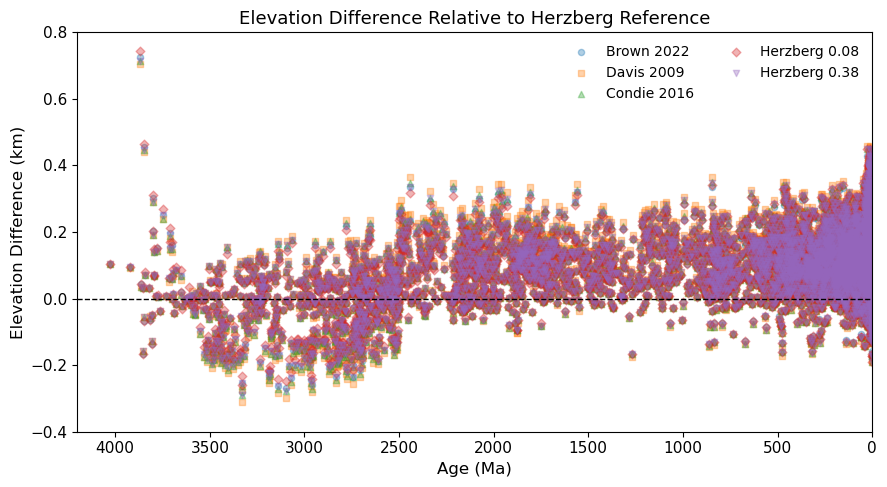

Figure saved to: /Users/jianpingzhou/work/Papers/Geology/Geology/revision/figures/elevation_difference_models.pdf


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# File path
# ------------------------------------------------------------
file_path = "/Users/jianpingzhou/work/Papers/Geology/Geology/revision/dataset/Global_crustal_thickness_with_paleo_coords.csv"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# Age column
# ------------------------------------------------------------
age_col = "Age_Ma"

# ------------------------------------------------------------
# Elevation models
# ------------------------------------------------------------
elevation_models = {
    "Brown 2022": "Brown_Isostatic_Elevation_absolute_km",
    "Davis 2009": "Davis_Isostatic_Elevation_absolute_km",
    "Condie 2016": "Condie_Isostatic_Elevation_absolute_km",
    "Herzberg 0.08": "Herz_0.08_Isostatic_Elevation_absolute_km",
    "Herzberg 0.38": "Herz_0.38 Isostatic_Elevation_absolute_km"
}

# Reference model
baseline = "Isostatic_Elevation_absolute_km"

# ------------------------------------------------------------
# Group data by age (median)
# ------------------------------------------------------------
df_grouped = df.groupby(age_col).median(numeric_only=True).reset_index()

# ------------------------------------------------------------
# Plot settings (publication quality)
# ------------------------------------------------------------
plt.figure(figsize=(9,5))

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10
})

markers = ["o","s","^","D","v"]

# ------------------------------------------------------------
# Plot differences
# ------------------------------------------------------------
for i,(name,col) in enumerate(elevation_models.items()):

    diff = df_grouped[col] - df_grouped[baseline]

    plt.scatter(
        df_grouped[age_col],
        diff,
        marker=markers[i],
        s=20,
        alpha=0.35,
        label=name
    )

# ------------------------------------------------------------
# Reference zero line
# ------------------------------------------------------------
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------
plt.gca().invert_xaxis()

plt.xlabel("Age (Ma)")
plt.ylabel("Elevation Difference (km)")
plt.title("Elevation Difference Relative to Herzberg Reference")

# Accurate geological ticks
plt.xticks(np.arange(0, 4500, 500))

# y-axis ticks
plt.yticks(np.arange(-0.4, 0.8, 0.2))

plt.xlim(4200,0)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
plt.legend(frameon=False, ncol=2)

plt.tight_layout()

# ------------------------------------------------------------
# Save PDF
# ------------------------------------------------------------
output_path = "/Users/jianpingzhou/work/Papers/Geology/Geology/revision/figures/elevation_difference_models.pdf"

plt.savefig(output_path, format="pdf", bbox_inches="tight")

plt.show()

print("Figure saved to:", output_path)